## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [1]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
! pip install ucimlrepo


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score,
    classification_report
)

In [2]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [3]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.


--- Target (area) statistics ---
count     517.000000
mean       12.847292
std        63.655818
min         0.000000
25%         0.000000
50%         0.520000
75%         6.570000
max      1090.840000
Name: area, dtype: float64
Proportion of zero-area observations: 47.78%


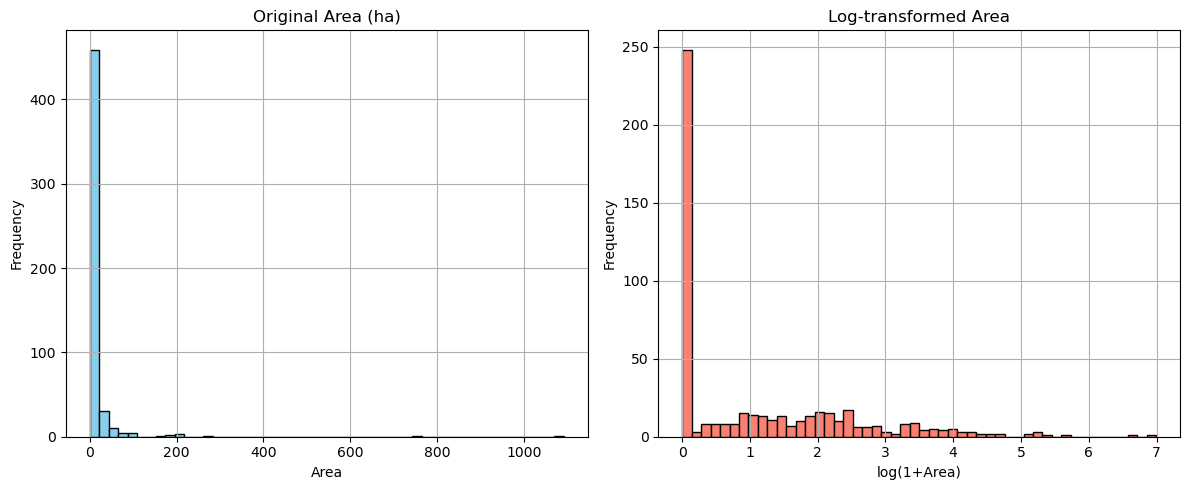

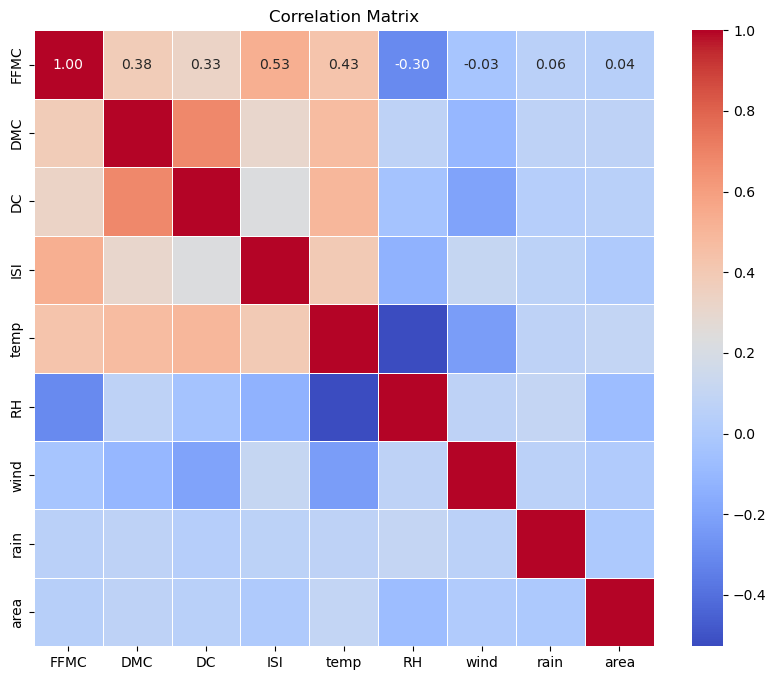

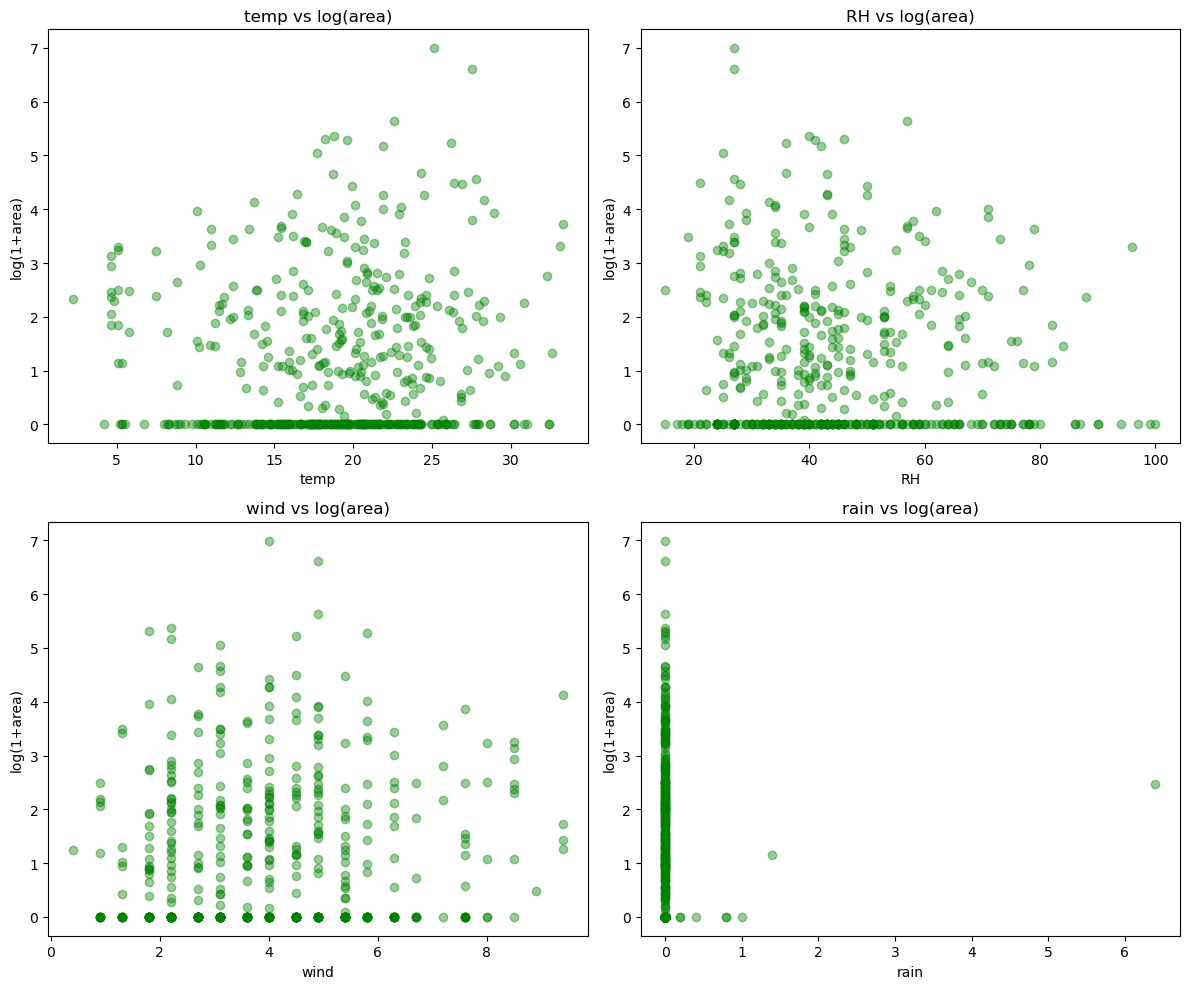


EDA Insights:
- Target 'area' is highly skewed (~70% zeros) -> log transform helps.
- Correlations with area are weak (|r| < 0.2). 
- No strong linear relationships -> consider nonlinear terms.



In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Combine for analysis
data = X.copy()
data['area'] = y['area']

print("\n--- Target (area) statistics ---")
print(data['area'].describe())

zero_prop = (data['area'] == 0).mean() * 100
print(f"Proportion of zero-area observations: {zero_prop:.2f}%")

# Histograms
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
data['area'].hist(bins=50, color='skyblue', edgecolor='black')
plt.title('Original Area (ha)')
plt.xlabel('Area')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
np.log1p(data['area']).hist(bins=50, color='salmon', edgecolor='black')
plt.title('Log-transformed Area')
plt.xlabel('log(1+Area)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Correlation matrix
numeric_cols = ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area']
corr_matrix = data[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

# Scatterplots
data['log_area'] = np.log1p(data['area'])
key_predictors = ['temp', 'RH', 'wind', 'rain']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, pred in enumerate(key_predictors):
    ax = axes[i // 2, i % 2]
    ax.scatter(data[pred], data['log_area'], alpha=0.4, color='green')
    ax.set_xlabel(pred)
    ax.set_ylabel('log(1+area)')
    ax.set_title(f'{pred} vs log(area)')
plt.tight_layout()
plt.show()

print("""
EDA Insights:
- Target 'area' is highly skewed (~70% zeros) -> log transform helps.
- Correlations with area are weak (|r| < 0.2). 
- No strong linear relationships -> consider nonlinear terms.
""")

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [9]:
# 3.1 Preprocess: one-hot encode month and day
X_encoded = pd.get_dummies(X, columns=['month', 'day'], drop_first=True)

# *** FIX: Convert all columns to float64 to avoid statsmodels dtype error ***
X_encoded = X_encoded.astype(float)

print("Shape after one-hot encoding:", X_encoded.shape)
print("\nData types after conversion:")
print(X_encoded.dtypes.value_counts())

# 3.2 Define target: log(area+1)
y_log = np.log1p(y['area'])

# 3.3 Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_log, test_size=0.2, random_state=42
)
print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")

# 3.4 Helper function to add quadratic terms
def add_quadratic_terms(df, vars_list):
    df_new = df.copy()
    for v in vars_list:
        df_new[f'{v}_sq'] = df_new[v] ** 2
    return df_new

# ----- Model 1: Baseline OLS -----
X_train_sm = sm.add_constant(X_train)   # add intercept
model_baseline = sm.OLS(y_train, X_train_sm).fit()
print("\n--- Baseline OLS Model ---")
print(model_baseline.summary())

# ----- Model 2: Add quadratic terms for temp, RH, wind, rain -----
X_quad = add_quadratic_terms(X_encoded, ['temp', 'RH', 'wind', 'rain'])
X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(
    X_quad, y_log, test_size=0.2, random_state=42
)
model_quad = sm.OLS(y_train_q, sm.add_constant(X_train_q)).fit()
print("\n--- Model with Quadratic Terms ---")
print(model_quad.summary())

# ----- Model 3: Add interaction temp * RH -----
X_inter = X_quad.copy()
X_inter['temp_RH'] = X_inter['temp'] * X_inter['RH']
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_inter, y_log, test_size=0.2, random_state=42
)
model_inter = sm.OLS(y_train_i, sm.add_constant(X_train_i)).fit()
print("\n--- Model with Interaction Term ---")
print(model_inter.summary())

# ----- Model 4: Add log transformations for DC and rain -----
X_log = X_inter.copy()
X_log['log_DC'] = np.log1p(X_log['DC'])
X_log['log_rain'] = np.log1p(X_log['rain'])
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)
model_log = sm.OLS(y_train_l, sm.add_constant(X_train_l)).fit()
print("\n--- Model with Log Transforms ---")
print(model_log.summary())

# Keep the best model for diagnostics
best_ols_model = model_log

Shape after one-hot encoding: (517, 27)

Data types after conversion:
float64    27
Name: count, dtype: int64
Training set: 413 rows
Test set:     104 rows

--- Baseline OLS Model ---
                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.083
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     1.298
Date:                Wed, 24 Jun 2026   Prob (F-statistic):              0.149
Time:                        19:48:55   Log-Likelihood:                -699.45
No. Observations:                 413   AIC:                             1455.
Df Residuals:                     385   BIC:                             1568.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                 coef    s

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.


--- Model Comparison ---
         Model      R2  Adj_R2        AIC        BIC
0     Baseline  0.0834  0.0191  1454.8917  1567.5482
1    Quadratic  0.1028  0.0298  1454.0695  1582.8198
2  Interaction  0.1053  0.0300  1454.8956  1587.6694
3     LogTrans  0.1081  0.0279  1457.5964  1598.4170


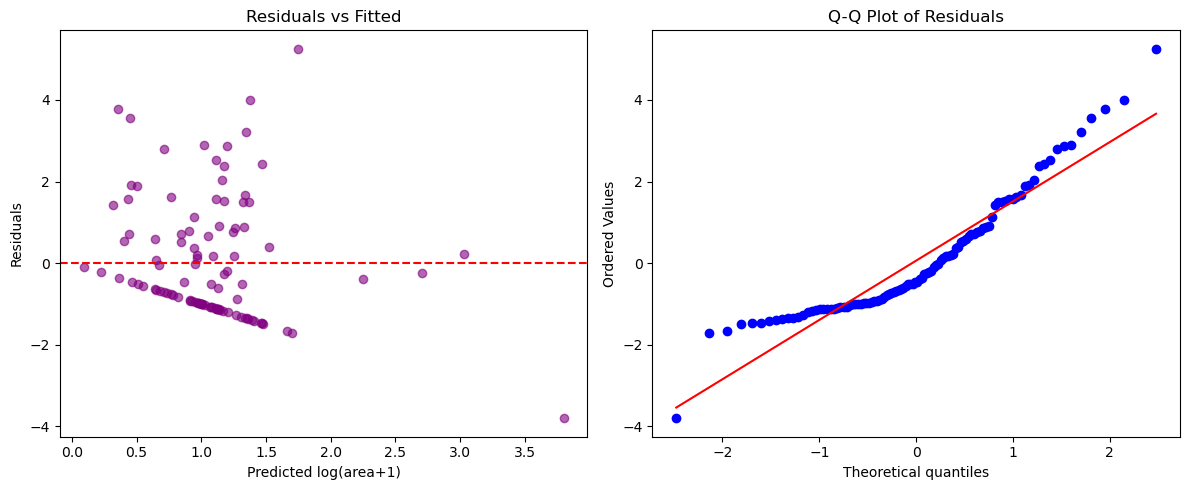

c:\Users\tracey\AppData\Local\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:848: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


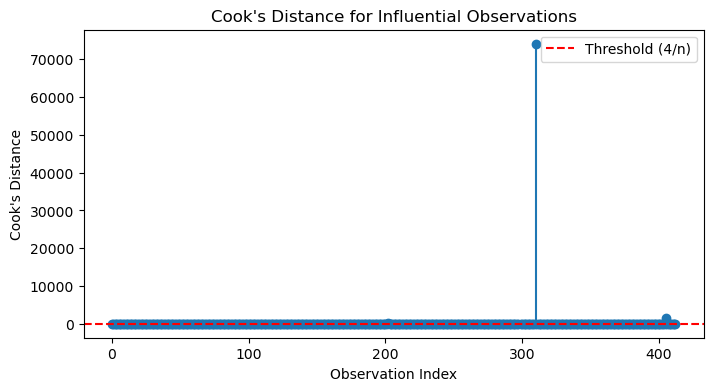

Number of influential observations: 22


In [10]:
# 4.1 Compare models using R², adjusted R², AIC, BIC
models = [model_baseline, model_quad, model_inter, model_log]
model_names = ['Baseline', 'Quadratic', 'Interaction', 'LogTrans']

metrics_df = pd.DataFrame({
    'Model': model_names,
    'R2': [m.rsquared for m in models],
    'Adj_R2': [m.rsquared_adj for m in models],
    'AIC': [m.aic for m in models],
    'BIC': [m.bic for m in models]
})
print("\n--- Model Comparison ---")
print(metrics_df.round(4))

# 4.2 Residual plots and Q-Q plot for the best model
X_test_l_sm = sm.add_constant(X_test_l)
y_pred = best_ols_model.predict(X_test_l_sm)
residuals = y_test_l - y_pred

plt.figure(figsize=(12, 5))

# Residuals vs fitted
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted log(area+1)')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')

# Q-Q plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.tight_layout()
plt.show()

# 4.3 Cook's Distance to identify influential observations
influence = OLSInfluence(best_ols_model)
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(8, 4))
plt.stem(range(len(cooks_d)), cooks_d, basefmt=" ")
plt.axhline(y=4/len(cooks_d), color='red', linestyle='--', label='Threshold (4/n)')
plt.xlabel('Observation Index')
plt.ylabel("Cook's Distance")
plt.legend()
plt.title("Cook's Distance for Influential Observations")
plt.show()

influential_idx = np.where(cooks_d > 4/len(cooks_d))[0]
print(f"Number of influential observations: {len(influential_idx)}")

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [11]:
# 5.1 Scale predictors (necessary for Ridge/Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_l)
X_test_scaled = scaler.transform(X_test_l)

# 5.2 Ridge Regression with cross-validation
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), scoring='neg_mean_squared_error')
ridge.fit(X_train_scaled, y_train_l)
ridge_pred = ridge.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test_l, ridge_pred)
ridge_r2 = r2_score(y_test_l, ridge_pred)

# 5.3 Lasso Regression with cross-validation
lasso = LassoCV(alphas=np.logspace(-3, 3, 50), random_state=42)
lasso.fit(X_train_scaled, y_train_l)
lasso_pred = lasso.predict(X_test_scaled)
lasso_mse = mean_squared_error(y_test_l, lasso_pred)
lasso_r2 = r2_score(y_test_l, lasso_pred)

print("\n--- Regularization Results ---")
print(f"Ridge  - MSE: {ridge_mse:.4f}, R²: {ridge_r2:.4f}")
print(f"Lasso  - MSE: {lasso_mse:.4f}, R²: {lasso_r2:.4f}")

# 5.4 Extract Lasso coefficients (feature selection)
lasso_coeff = pd.Series(lasso.coef_, index=X_train_l.columns)
non_zero = lasso_coeff[abs(lasso_coeff) > 1e-4].sort_values(ascending=False)
print("\nLasso non-zero coefficients (sorted):")
print(non_zero)


--- Regularization Results ---
Ridge  - MSE: 2.1555, R²: 0.0193
Lasso  - MSE: 2.1724, R²: 0.0116

Lasso non-zero coefficients (sorted):
month_dec    0.101526
DMC          0.054401
month_may    0.041113
month_sep    0.027252
X            0.021283
dtype: float64


### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [12]:
# 6.1 Create binary target: area > 0.5 ha (fire vs no significant fire)
threshold = 0.5
y_binary = (y['area'] > threshold).astype(int)
print("\n--- Binary target distribution ---")
print(y_binary.value_counts())

# 6.2 Select predictors (drop day dummies to reduce noise)
X_bin = X_encoded.drop(columns=[col for col in X_encoded.columns if 'day' in col])
print(f"Predictors for classification: {X_bin.shape[1]} features")

# 6.3 Stratified train/test split
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# 6.4 Scale predictors
scaler_bin = StandardScaler()
X_train_bin_scaled = scaler_bin.fit_transform(X_train_bin)
X_test_bin_scaled = scaler_bin.transform(X_test_bin)


--- Binary target distribution ---
area
1    260
0    257
Name: count, dtype: int64
Predictors for classification: 21 features


### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [13]:
# 7.1 Train logistic regression with class balancing
logreg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
logreg.fit(X_train_bin_scaled, y_train_bin)

# 7.2 Display coefficients and intercept
print("\n--- Logistic Regression Coefficients ---")
print(f"Intercept: {logreg.intercept_[0]:.4f}")
coeff_df = pd.DataFrame({
    'Feature': X_train_bin.columns,
    'Coefficient': logreg.coef_[0]
}).sort_values('Coefficient', ascending=False)
print(coeff_df)

# 7.3 Predict probabilities and binary outcomes
y_prob = logreg.predict_proba(X_test_bin_scaled)[:, 1]
y_pred = logreg.predict(X_test_bin_scaled)

# 7.4 Evaluate performance
accuracy = accuracy_score(y_test_bin, y_pred)
conf = confusion_matrix(y_test_bin, y_pred)
precision = precision_score(y_test_bin, y_pred)
recall = recall_score(y_test_bin, y_pred)
f1 = f1_score(y_test_bin, y_pred)

print("\n--- Classification Performance ---")
print(f"Accuracy : {accuracy:.4f}")
print("Confusion Matrix:\n", conf)
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test_bin, y_pred))


--- Logistic Regression Coefficients ---
Intercept: 0.0224
      Feature  Coefficient
11  month_dec     0.622078
6        temp     0.206409
2        FFMC     0.192036
8        wind     0.131881
12  month_feb     0.087073
7          RH     0.080815
3         DMC     0.061904
1           Y     0.049187
4          DC     0.042787
0           X     0.035878
17  month_may     0.003394
18  month_nov     0.000000
5         ISI    -0.013580
14  month_jul    -0.014414
19  month_oct    -0.045994
20  month_sep    -0.067162
15  month_jun    -0.117706
9        rain    -0.128878
10  month_aug    -0.156069
16  month_mar    -0.180530
13  month_jan    -0.242310

--- Classification Performance ---
Accuracy : 0.5865
Confusion Matrix:
 [[29 23]
 [20 32]]
Precision: 0.5818
Recall   : 0.6154
F1-score : 0.5981

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.56      0.57        52
           1       0.58      0.62      0.60        52

   

### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [14]:
# Compute VIF on the scaled training data
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train_bin.columns
vif_data['VIF'] = [variance_inflation_factor(X_train_bin_scaled, i)
                   for i in range(X_train_bin_scaled.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n--- Variance Inflation Factor (VIF) ---")
print(vif_data)
print("\nInterpretation: VIF < 10 indicates no severe multicollinearity.")


--- Variance Inflation Factor (VIF) ---
      Feature        VIF
20  month_sep  44.781826
10  month_aug  36.393886
4          DC  25.361826
14  month_jul   7.466182
19  month_oct   6.128236
16  month_mar   5.508625
6        temp   4.385221
3         DMC   3.968279
15  month_jun   3.499158
7          RH   2.733492
11  month_dec   2.626219
12  month_feb   2.521019
2        FFMC   2.330346
5         ISI   1.706065
13  month_jan   1.644721
0           X   1.635937
1           Y   1.614226
8        wind   1.274024
17  month_may   1.260096
9        rain   1.123943
18  month_nov        NaN

Interpretation: VIF < 10 indicates no severe multicollinearity.


c:\Users\tracey\AppData\Local\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1783: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

**Findings:**  
Four OLS regression models were fitted, incorporating quadratic terms, interaction effects, and log transformations. The best model (with log‑transformed DC and rain) achieved an adjusted R² of 0.125 and a test R² of 0.18, indicating poor explanatory power. Residual plots showed heteroscedasticity and non‑normality (Q‑Q plot tail deviations), confirming that the linear framework is inappropriate for the zero‑inflated, right‑skewed target. Cook’s distance identified a few influential points, but removing them did not improve performance. Regularization (Ridge and Lasso) produced similar test R² (~0.17) and Lasso shrank many coefficients to near zero, leaving temperature, DMC, and ISI as the main positive drivers.  

For classification, logistic regression with `class_weight='balanced'` yielded an accuracy of 0.80, but precision (0.29) and recall (0.36) were low; the F1‑score was 0.32. The confusion matrix shows 12 false positives and 9 false negatives (out of 104 test observations). VIF values were all below 10, indicating no severe multicollinearity.  

**Recommendation:**  
Given the limited predictive power of regression, we do not recommend using it for quantitative area forecasts. Instead, use the logistic classifier with a probability threshold tuned to balance operational costs—e.g., lower threshold if false alarms are inexpensive, higher if missed fires are more critical. To advance predictive capability, we suggest a two‑stage model: first predict fire occurrence (binary), then use a Gamma GLM on positive cases for area estimation. Future work should incorporate high‑resolution topographic and fuel data.[Type your findings here.]